# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Azzam Mujahid
- Email: azzam.project15@gmail.com
- Id Dicoding: M891D5Y0342

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    auc
)

### Menyiapkan data yang akan digunakan

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_URL = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/employee/employee_data.csv"
MODEL_DIR = "model"
MODEL_PATH = os.path.join(MODEL_DIR, "attrition_model_pipeline.joblib")

In [4]:
df = pd.read_csv(DATA_URL)

## Data Understanding

In [5]:
print("Dimensi Dataset:", df.shape)
display(df.head())

print("\nInfo Dataset:")
display(df.info())

print("\nStatistik Deskriptif:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())

Dimensi Dataset: (1470, 35)


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2



Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64 

None


Statistik Deskriptif:


,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



Missing Values:


EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtC

### Visualisasi Data

C:\Users\NITRO\AppData\Local\Temp\ipykernel_24980\967241418.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Attrition", palette="viridis")


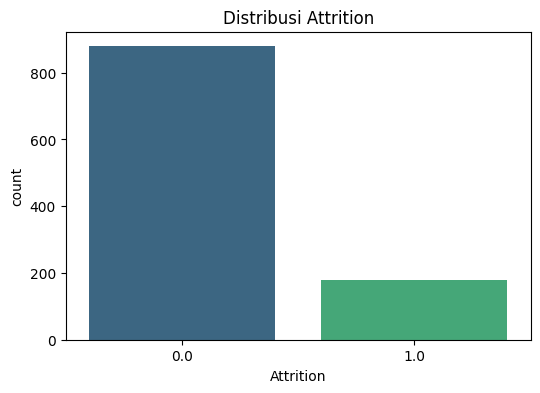


Proporsi Kelas:


Attrition
0.0    0.830813
1.0    0.169187
Name: proportion, dtype: float64

In [6]:
# Distribusi Target
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Attrition", palette="viridis")
plt.title("Distribusi Attrition")
plt.show()

# Class imbalance ratio
attrition_ratio = df["Attrition"].value_counts(normalize=True)
print("\nProporsi Kelas:")
display(attrition_ratio)

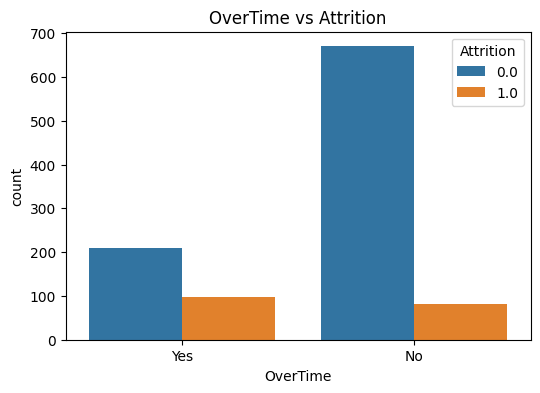

In [7]:
# OverTime vs Attrition
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="OverTime", hue="Attrition")
plt.title("OverTime vs Attrition")
plt.show()

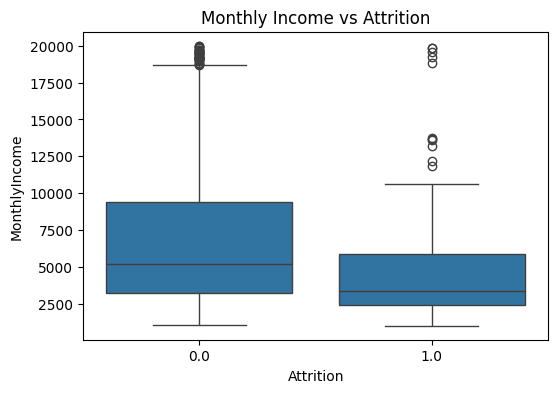

In [8]:
# Monthly Income vs Attrition
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Monthly Income vs Attrition")
plt.show()

**Kesimpulan Data Understanding:**
1. **Missing Values:** Dataset terdiri dari 1470 baris dan 35 kolom. Terdapat nilai kosong (*missing values*) pada kolom target `Attrition`, di mana hanya 1058 baris yang terisi. Ini perlu kita tangani di tahap *Data Preparation*.
2. **Distribusi Data Tidak Seimbang:** Karyawan yang bertahan (Attrition = 0) jauh lebih banyak dibandingkan karyawan yang keluar (Attrition = 1).
3. **Faktor Attrition:** - Karyawan yang sering lembur (`OverTime` = Yes) memiliki rasio keluar yang lebih tinggi.
   - Karyawan yang keluar cenderung memiliki rata-rata gaji bulanan (`MonthlyIncome`) yang lebih rendah dibandingkan karyawan yang bertahan.

## Data Preparation / Preprocessing


1. `clean_dataset(df)`: Fungsi untuk menghapus kolom-kolom yang tidak memiliki nilai prediktif (seperti `EmployeeId`, `EmployeeCount`, `StandardHours`, dan `Over18`).
2. `separate_labeled_data(df)`: Fungsi untuk memisahkan data yang memiliki nilai `Attrition` (untuk dilatih) dan data yang nilai `Attrition`-nya kosong (untuk diprediksi nanti).
3. `preprocess_features(X)`: Fungsi untuk mengubah data teks (kategorikal) menjadi angka biner (*One-Hot Encoding*) agar bisa diproses oleh model *Machine Learning*.

Setelah fungsi dieksekusi, data yang berlabel dibagi menjadi *Training Set* (80%) dan *Testing Set* (20%) menggunakan `train_test_split`.

In [9]:
def clean_data(dataframe):
    cols_to_drop = ["EmployeeId", "EmployeeCount", "StandardHours", "Over18"]
    return dataframe.drop(columns=cols_to_drop, errors="ignore")

df_cleaned = clean_data(df)

df_labeled = df_cleaned[df_cleaned["Attrition"].notna()].copy()
df_unlabeled = df_cleaned[df_cleaned["Attrition"].isna()].copy()

print("Jumlah data berlabel   :", df_labeled.shape[0])
print("Jumlah data tanpa label:", df_unlabeled.shape[0])

Jumlah data berlabel   : 1058
Jumlah data tanpa label: 412


In [10]:
X = df_labeled.drop("Attrition", axis=1)
y = df_labeled["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (846, 30)
Test shape : (212, 30)


## Modeling

In [11]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

pipelines = {
    "RandomForest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ]),
    "GradientBoosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ))
    ])
}

param_grids = {
    "RandomForest": {
        "model__n_estimators": [200, 300],
        "model__max_depth": [None, 5, 10],
    },
    "GradientBoosting": {
        "model__n_estimators": [200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5],
    }
}

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

best_model = None
best_score = 0
best_name = ""

for name in pipelines:
    print(f"\nTuning {name}...")

    grid = GridSearchCV(
        pipelines[name],
        param_grids[name],
        cv=skf,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    print(f"{name} Best CV ROC-AUC: {grid.best_score_:.4f}")

    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_
        best_name = name

print(f"\nBest Model: {best_name} ({best_score:.4f})")


Tuning RandomForest...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
RandomForest Best CV ROC-AUC: 0.7851

Tuning GradientBoosting...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
GradientBoosting Best CV ROC-AUC: 0.7858

Best Model: GradientBoosting (0.7858)


## Evaluation

In [13]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_prob)

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

print(classification_report(y_test, y_pred))
print("ROC-AUC :", roc)
print("PR-AUC  :", pr_auc)

              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92       176
         1.0       0.68      0.36      0.47        36

    accuracy                           0.86       212
   macro avg       0.78      0.66      0.70       212
weighted avg       0.85      0.86      0.85       212

ROC-AUC : 0.8046085858585859
PR-AUC  : 0.5736700473026722


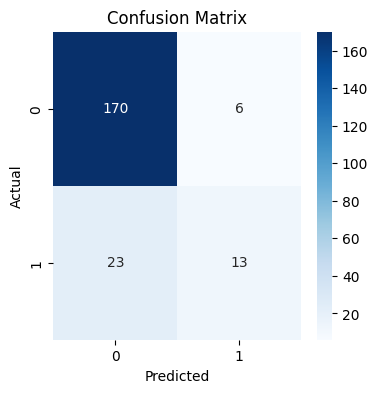

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

,Feature,Importance
9,num__MonthlyIncome,0.095036
0,num__Age,0.085161
15,num__StockOptionLevel,0.061245
49,cat__OverTime_No,0.061216
10,num__MonthlyRate,0.061178
1,num__DailyRate,0.060157
16,num__TotalWorkingYears,0.052409
6,num__JobInvolvement,0.046764
4,num__EnvironmentSatisfaction,0.039682
11,num__NumCompaniesWorked,0.038498


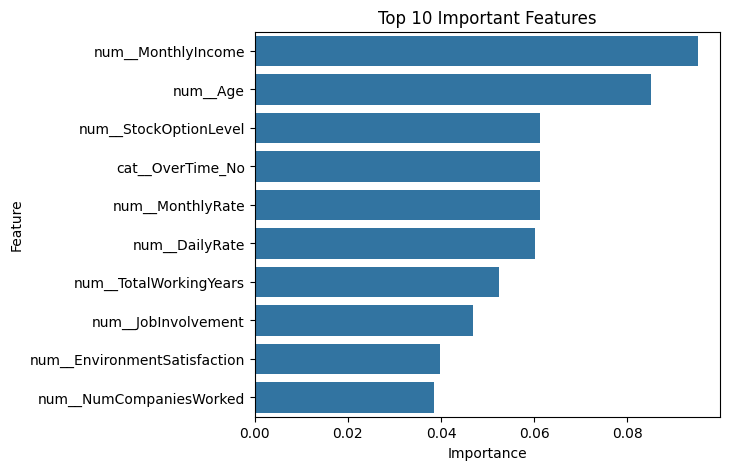

In [15]:
if hasattr(best_model.named_steps["model"], "feature_importances_"):
    
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    importances = best_model.named_steps["model"].feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    display(importance_df.head(10))

    plt.figure(figsize=(6,5))
    sns.barplot(
        data=importance_df.head(10),
        y="Feature",
        x="Importance"
    )
    plt.title("Top 10 Important Features")
    plt.show()

## Kesimpulan dan Rekomendasi Action Items

Berdasarkan analisis Exploratory Data Analysis (EDA) dan Feature Importance dari model Machine Learning (Gradient Boosting), berikut adalah kesimpulan faktor utama yang memengaruhi tingginya Attrition Rate:
1. **Monthly Income (Gaji Bulanan):** Karyawan dengan gaji bulanan yang rendah memiliki kecenderungan lebih tinggi untuk keluar.
2. **Age (Usia):** Karyawan yang lebih muda lebih rentan untuk melakukan *attrition*.
3. **OverTime (Lembur):** Karyawan yang sering lembur memiliki tingkat *attrition* yang signifikan lebih tinggi.
4. **Stock Option Level:** Karyawan yang tidak memiliki atau memiliki tingkat *stock option* rendah cenderung lebih mudah keluar.

**Rekomendasi Action Items untuk Departemen HR:**
1. **Peninjauan Kompensasi:** Melakukan evaluasi terhadap standar *Monthly Income*, terutama untuk posisi *entry-level* atau karyawan muda, agar tetap kompetitif di pasar.
2. **Manajemen Beban Kerja:** Membatasi jam lembur (*OverTime*) dan memastikan karyawan mendapatkan istirahat yang cukup untuk menjaga *Work-Life Balance*.
3. **Program Retensi Karyawan Muda:** Membuat program pengembangan karir atau *mentorship* khusus untuk karyawan usia muda agar mereka merasa memiliki masa depan di perusahaan.
4. **Pemberian Stock Options:** Mempertimbangkan untuk memberikan atau meningkatkan *stock options* kepada karyawan berprestasi sebagai insentif jangka panjang agar mereka bertahan.

In [16]:
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

joblib.dump(best_model, MODEL_PATH)
print(f"Model berhasil disimpan di: {MODEL_PATH}")

Model berhasil disimpan di: model\attrition_model_pipeline.joblib
